<a href="https://colab.research.google.com/github/PrashVenga/AMLDM/blob/IBM-CW2-PART-1/Copy_of_IBM_CW2_(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Mount Google Drive to access files
from google.colab import drive
drive.mount('/content/drive')

# Load the dataset
# The previous error 'FileNotFoundError' indicates that the system could not find the CSV file
# at the specified path: '/content/drive/MyDrive/IBM HR Employee Attrition.csv'.
# This usually happens if Google Drive is not mounted or the file path is incorrect.
# Please ensure Google Drive is mounted and the path to your CSV file is accurate.
df = pd.read_csv('/content/drive/MyDrive/IBM HR Employee Attrition.csv')

# Display the first 5 rows and basic info
print("Dataset Shape:", df.shape)
df.head()

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset Shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [7]:
# Check data types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [8]:
# Statistical summary for numerical features
numerical_summary = df.describe()

# Statistical summary for categorical features
categorical_summary = df.describe(include=['O'])

print("Numerical Summary:")
display(numerical_summary)
print("\nCategorical Summary:")
display(categorical_summary)

Numerical Summary:


,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000



Categorical Summary:


,Attrition,BusinessTravel,Department,EducationField,Gender,JobRole,MaritalStatus,Over18,OverTime
count,1470,1470,1470,1470,1470,1470,1470,1470,1470
unique,2,3,3,6,2,9,3,1,2
top,No,Travel_Rarely,Research & Development,Life Sciences,Male,Sales Executive,Married,Y,No
freq,1233,1043,961,606,882,326,673,1470,1054


In [9]:
# Check for missing values
missing_values = df.isnull().sum()

# Check for unique values in each column to find redundant data
unique_counts = df.nunique()

quality_report = pd.DataFrame({
    'Missing Values': missing_values,
    'Unique Values': unique_counts
})

print(quality_report)

                          Missing Values  Unique Values
Age                                    0             43
Attrition                              0              2
BusinessTravel                         0              3
DailyRate                              0            886
Department                             0              3
DistanceFromHome                       0             29
Education                              0              5
EducationField                         0              6
EmployeeCount                          0              1
EmployeeNumber                         0           1470
EnvironmentSatisfaction                0              4
Gender                                 0              2
HourlyRate                             0             71
JobInvolvement                         0              4
JobLevel                               0              5
JobRole                                0              9
JobSatisfaction                        0        

/tmp/ipython-input-3459751283.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Attrition', data=df, palette='viridis')


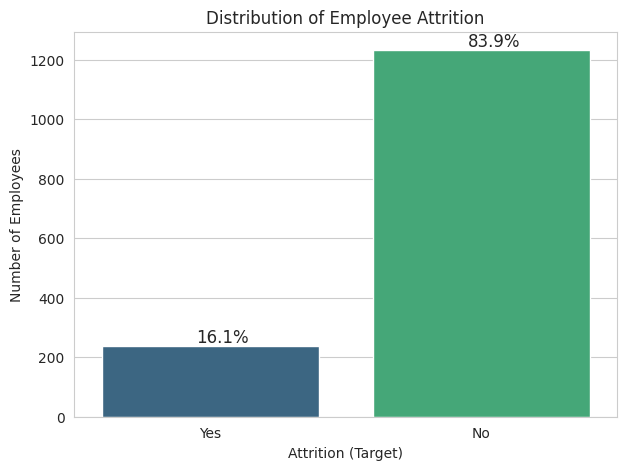

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set the visual style
sns.set_style("whitegrid")

# Plot the distribution of Attrition
plt.figure(figsize=(7, 5))
ax = sns.countplot(x='Attrition', data=df, palette='viridis')
plt.title('Distribution of Employee Attrition')
plt.xlabel('Attrition (Target)')
plt.ylabel('Number of Employees')

# Add percentage labels
total = len(df['Attrition'])
for p in ax.patches:
    percentage = '{:.1f}%'.format(100 * p.get_height()/total)
    x = p.get_x() + p.get_width() / 2 - 0.05
    y = p.get_height()
    ax.annotate(percentage, (x, y), size = 12, va='bottom')

plt.show()

/tmp/ipython-input-200596478.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Attrition', y=col, data=df, palette='magma')
/tmp/ipython-input-200596478.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Attrition', y=col, data=df, palette='magma')
/tmp/ipython-input-200596478.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Attrition', y=col, data=df, palette='magma')
/tmp/ipython-input-200596478.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` varia

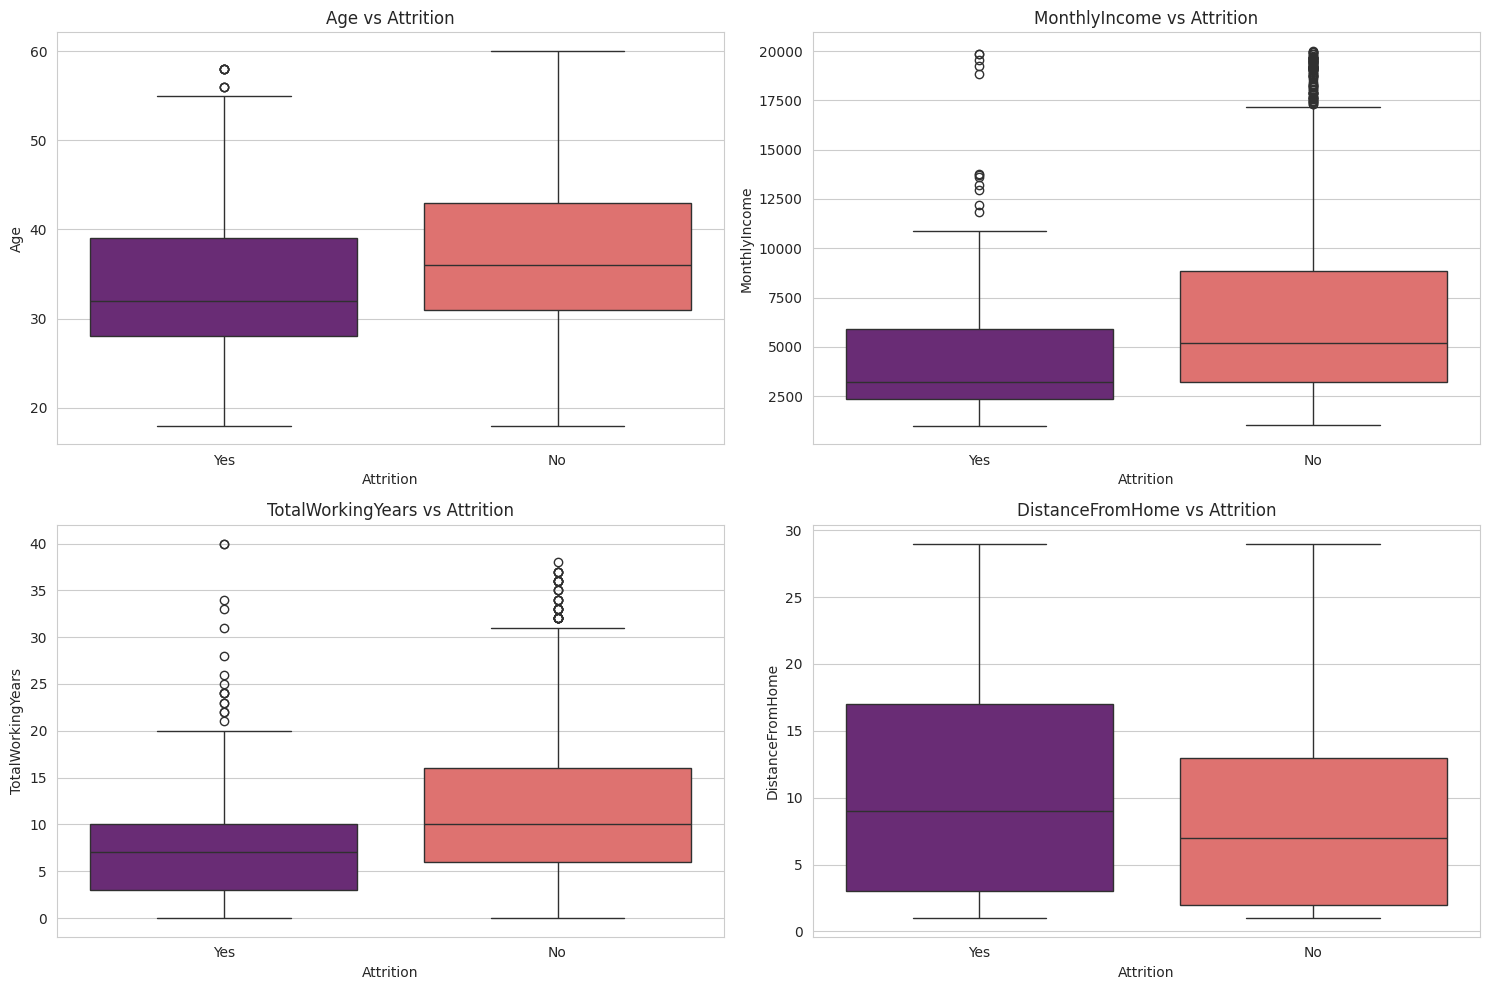

In [11]:
# List of key numerical features to explore
features = ['Age', 'MonthlyIncome', 'TotalWorkingYears', 'DistanceFromHome']

plt.figure(figsize=(15, 10))

for i, col in enumerate(features, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x='Attrition', y=col, data=df, palette='magma')
    plt.title(f'{col} vs Attrition')

plt.tight_layout()
plt.show()

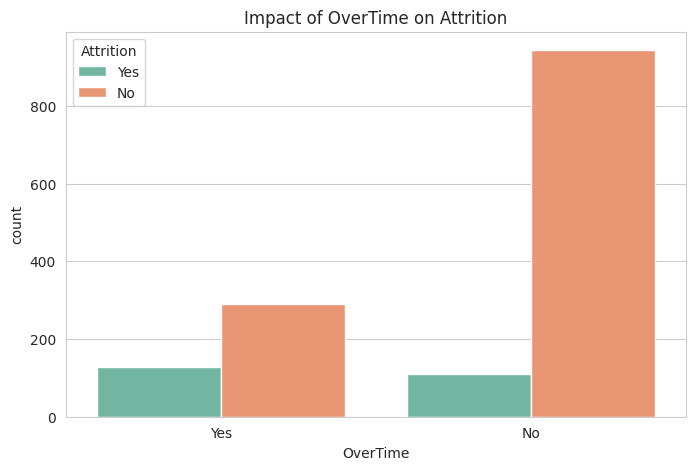

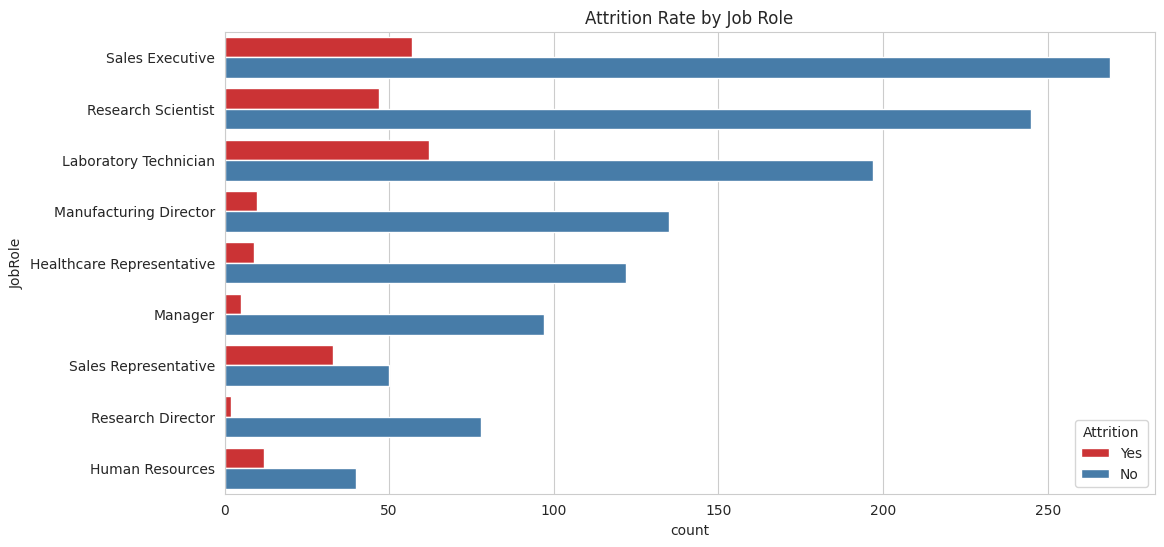

In [12]:
# Analyzing OverTime vs Attrition
plt.figure(figsize=(8, 5))
sns.countplot(x='OverTime', hue='Attrition', data=df, palette='Set2')
plt.title('Impact of OverTime on Attrition')
plt.show()

# Analyzing JobRole vs Attrition
plt.figure(figsize=(12, 6))
sns.countplot(y='JobRole', hue='Attrition', data=df, palette='Set1')
plt.title('Attrition Rate by Job Role')
plt.show()

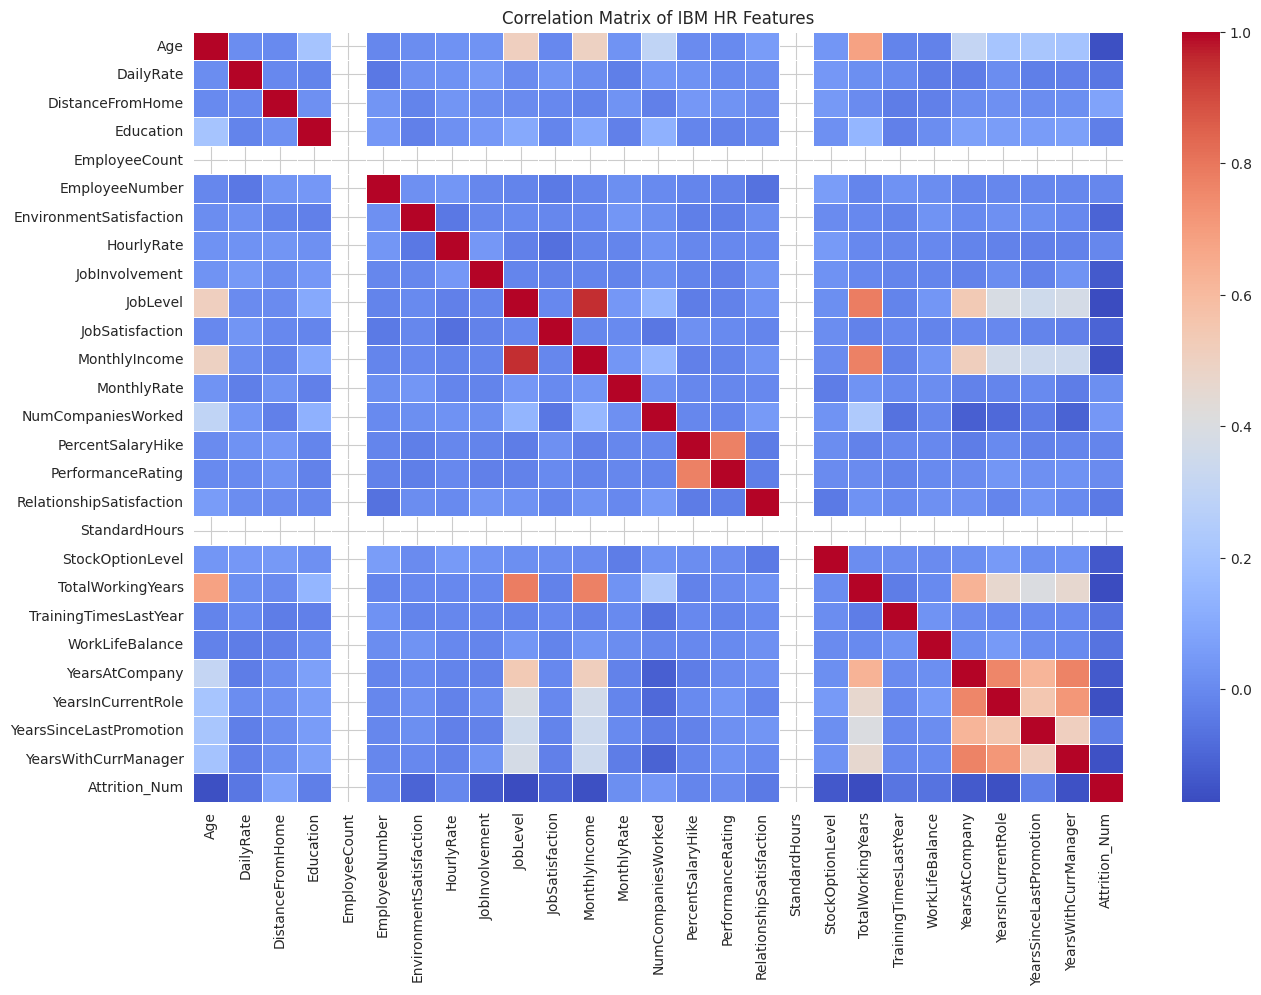

Correlation with Attrition:
Attrition_Num               1.000000
DistanceFromHome            0.077924
NumCompaniesWorked          0.043494
MonthlyRate                 0.015170
PerformanceRating           0.002889
HourlyRate                 -0.006846
EmployeeNumber             -0.010577
PercentSalaryHike          -0.013478
Education                  -0.031373
YearsSinceLastPromotion    -0.033019
RelationshipSatisfaction   -0.045872
DailyRate                  -0.056652
TrainingTimesLastYear      -0.059478
WorkLifeBalance            -0.063939
EnvironmentSatisfaction    -0.103369
JobSatisfaction            -0.103481
JobInvolvement             -0.130016
YearsAtCompany             -0.134392
StockOptionLevel           -0.137145
YearsWithCurrManager       -0.156199
Age                        -0.159205
MonthlyIncome              -0.159840
YearsInCurrentRole         -0.160545
JobLevel                   -0.169105
TotalWorkingYears          -0.171063
EmployeeCount                    NaN
StandardHo

In [13]:
# 1. Convert Attrition to numerical (1 for Yes, 0 for No) for correlation purposes
df['Attrition_Num'] = df['Attrition'].apply(lambda x: 1 if x == 'Yes' else 0)

# 2. Select only numerical columns
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
corr_matrix = df[numerical_cols].corr()

# 3. Plot the heatmap
plt.figure(figsize=(15, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Matrix of IBM HR Features')
plt.show()

# 4. Show correlation specifically with the target
print("Correlation with Attrition:")
print(corr_matrix['Attrition_Num'].sort_values(ascending=False))

In [14]:
# List of columns to drop
# - 'EmployeeCount', 'StandardHours', 'Over18': Zero variance/Constant
# - 'EmployeeNumber': Just an ID, no predictive power
# - Features with very low correlation (e.g., < 0.05) to Attrition:
#   'PerformanceRating', 'HourlyRate', 'PercentSalaryHike', 'MonthlyRate'

cols_to_drop = [
    'EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber',
    'PerformanceRating', 'HourlyRate', 'PercentSalaryHike', 'MonthlyRate'
]

# Drop the columns
df_cleaned = df.drop(columns=cols_to_drop)

print(f"Features removed: {cols_to_drop}")
print(f"New dataset shape: {df_cleaned.shape}")

# Optional: Drop the temporary Attrition_Num if you prefer to keep the original 'Yes/No' for now
# df_cleaned = df_cleaned.drop(columns=['Attrition_Num'])

Features removed: ['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber', 'PerformanceRating', 'HourlyRate', 'PercentSalaryHike', 'MonthlyRate']
New dataset shape: (1470, 28)


In [15]:
# 1. Define the columns identified as redundant or non-predictive
# EmployeeCount, StandardHours, Over18: Zero variance (constant values)
# EmployeeNumber: Unique identifier (random noise)
# PerformanceRating, HourlyRate, MonthlyRate: Negligible correlation in this specific data
cols_to_drop = [
    'EmployeeCount', 'StandardHours', 'Over18', 'EmployeeNumber',
    'PerformanceRating', 'HourlyRate', 'MonthlyRate'
]

# 2. Create the cleaned dataframe
df_final = df.drop(columns=cols_to_drop)

# 3. Verify the changes
print(f"Original columns: {df.shape[1]}")
print(f"Columns after dropping: {df_final.shape[1]}")
print("\nRemaining columns for analysis:")
print(df_final.columns.tolist())

# Check the first few rows of the cleaned data
df_final.head()

Original columns: 36
Columns after dropping: 29

Remaining columns for analysis:
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'Attrition_Num']


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition_Num
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,1,0,8,0,1,6,4,0,5,1
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,4,1,10,3,3,10,7,1,7,0
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,2,0,7,3,3,0,0,0,0,1
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,0,8,3,3,8,7,3,0,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,4,1,6,3,3,2,2,2,2,0


In [16]:
from sklearn.preprocessing import LabelEncoder

# Create a copy for analysis
df_importance = df_final.copy()

# Encode categorical features
le = LabelEncoder()
categorical_cols = df_importance.select_dtypes(include=['object']).columns

for col in categorical_cols:
    df_importance[col] = le.fit_transform(df_importance[col])

# Separate Features (X) and Target (y)
X = df_importance.drop('Attrition', axis=1)
y = df_importance['Attrition']

/tmp/ipython-input-4040856933.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='plasma')


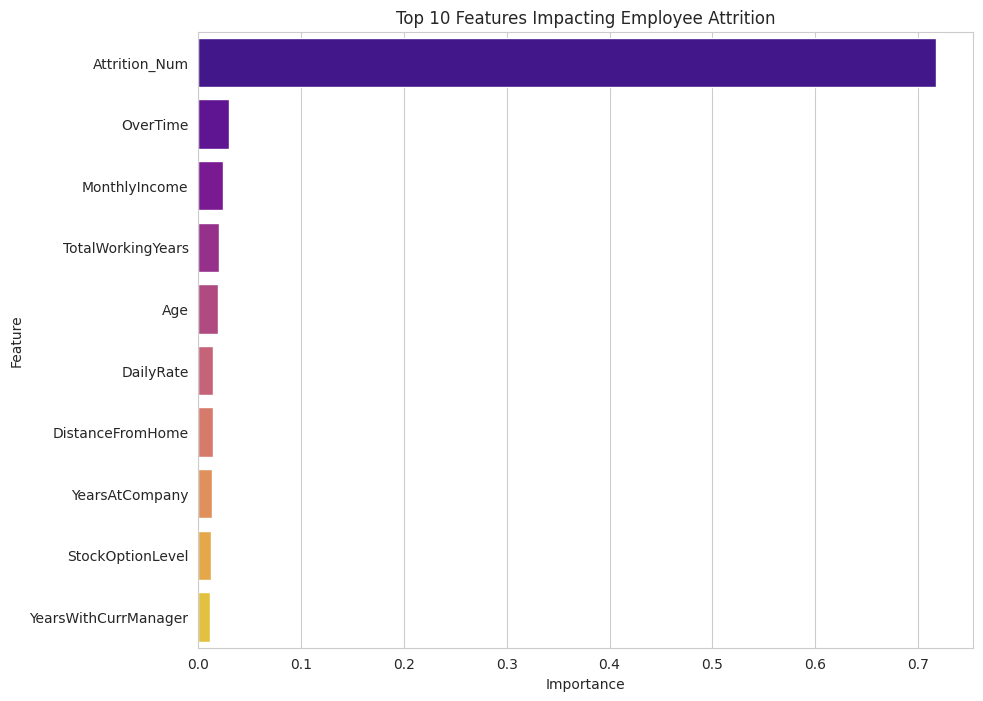

                 Feature  Importance
27         Attrition_Num    0.717888
16              OverTime    0.029690
14         MonthlyIncome    0.024398
20     TotalWorkingYears    0.020276
0                    Age    0.019478
2              DailyRate    0.014416
4       DistanceFromHome    0.013914
23        YearsAtCompany    0.012967
19      StockOptionLevel    0.011990
26  YearsWithCurrManager    0.011344


In [17]:
from sklearn.ensemble import RandomForestClassifier

# Initialize and fit the model
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)

# Get importance scores
importances = rf.feature_importances_
feature_names = X.columns
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

# Visualize the Top 10 Features
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df.head(10), palette='plasma')
plt.title('Top 10 Features Impacting Employee Attrition')
plt.show()

print(feature_importance_df.head(10))

In [18]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Convert categorical variables to numbers (One-Hot Encoding)
df_ml = pd.get_dummies(df_final, drop_first=True)

# 2. Separate Features (X) and Target (y)
X = df_ml.drop('Attrition_Yes', axis=1) # Target is now Attrition_Yes
y = df_ml['Attrition_Yes']

# 3. Split data into Training (80%) and Testing (20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# 4. Standardize the data (Scale the numbers so large values don't dominate)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Initialize models
log_reg = LogisticRegression()
dec_tree = DecisionTreeClassifier(max_depth=5)
rand_forest = RandomForestClassifier(n_estimators=100)

# Train and Predict
models = {"Logistic Regression": log_reg, "Decision Tree": dec_tree, "Random Forest": rand_forest}

for name, model in models.items():
    # Use scaled data for Logistic Regression
    if name == "Logistic Regression":
        model.fit(X_train_scaled, y_train)
        predictions = model.predict(X_test_scaled)
    else:
        model.fit(X_train, y_train)
        predictions = model.predict(X_test)

    print(f"--- {name} Performance ---")
    print(classification_report(y_test, predictions))

--- Logistic Regression Performance ---
              precision    recall  f1-score   support

       False       1.00      1.00      1.00       247
        True       1.00      1.00      1.00        47

    accuracy                           1.00       294
   macro avg       1.00      1.00      1.00       294
weighted avg       1.00      1.00      1.00       294

--- Decision Tree Performance ---
              precision    recall  f1-score   support

       False       1.00      1.00      1.00       247
        True       1.00      1.00      1.00        47

    accuracy                           1.00       294
   macro avg       1.00      1.00      1.00       294
weighted avg       1.00      1.00      1.00       294

--- Random Forest Performance ---
              precision    recall  f1-score   support

       False       1.00      1.00      1.00       247
        True       1.00      1.00      1.00        47

    accuracy                           1.00       294
   macro avg       1

In [20]:
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler

# 1. Select Key Numerical Features (Age, Income, YearsAtCompany, etc.)
features_for_clustering = ['Age', 'MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany', 'DistanceFromHome']
X_cluster = df_final[features_for_clustering]

# 2. Scaling is mandatory for clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# 3. K-Means Model
kmeans = KMeans(n_clusters=3, random_state=42)
df['KMeans_Labels'] = kmeans.fit_predict(X_scaled)

# 4. Hierarchical Model
hierarchical = AgglomerativeClustering(n_clusters=3)
df['Hierarchical_Labels'] = hierarchical.fit_predict(X_scaled)

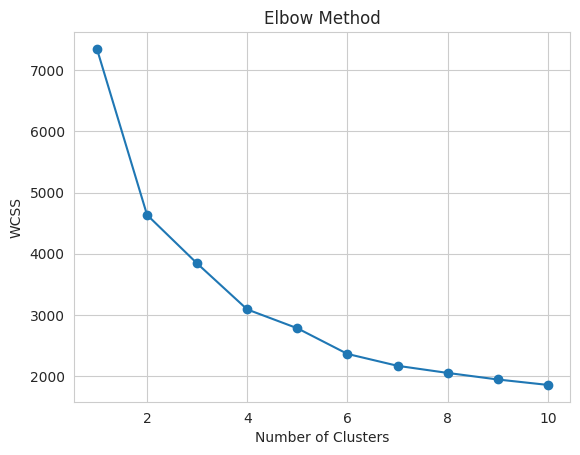

In [21]:
# Code to find the Elbow
wcss = []
for i in range(1, 11):
    km = KMeans(n_clusters=i, random_state=42)
    km.fit(X_scaled)
    wcss.append(km.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()